In [3]:
import os
import sys
import warnings
from pathlib import Path

import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from src.config.settings import load_config
from src.utils.logger import get_logger
from src.data.data_manager import DataManager
from src.backtest.backtester import Backtester
from src.strategies.momentum_strategy import MovingAverageCrossover

config = load_config()
logger = get_logger(__name__)
data_manager = DataManager(config=config)

Loading cofiguration from /home/ciprimarian/Repos/ Local Repos/tradingbot/src/config/trading_config.yaml...
2025-11-18 19:18:39,723 | INFO | src.data.market_data | Market Data handler initialized | base_url: https://data.alpaca.markets


## Modular Backtesting Framework

Prototyp backtesting using the project's Backtester class.

In [4]:
df = data_manager.load_data("engineered_features")
if df.empty:
    raise RuntimeError("Run 02_feature_engineering.ipynb before backtesting.")

df.tail()


2025-11-18 19:18:42,675 | INFO | src.data.data_manager | Loading dataset engineered_features from data/processed/engineered_features.parquet


,open,high,low,close,volume,sma_20,sma_50,rsi_14,return_1d,lag_close_1,day_of_week
t,,,,,,,,,,,
2024-05-17 04:00:00+00:00,943.69,947.4,918.06,924.79,35989353,879.3725,882.4177,59.353459,-0.019924,943.59,4
2024-05-20 04:00:00+00:00,937.50,952.0,934.40,947.80,31876446,887.0035,883.8681,65.995876,0.024881,924.79,0
2024-05-21 04:00:00+00:00,935.99,954.0,931.80,953.86,32894646,893.4850,885.7905,76.341057,0.006394,947.80,1
2024-05-22 04:00:00+00:00,954.59,960.2,932.49,949.50,54865849,901.1215,886.3979,71.649362,-0.004571,953.86,2
2024-05-23 04:00:00+00:00,1020.28,1063.2,1015.20,1037.99,83506528,911.7050,888.9801,77.827215,0.093196,949.50,3


## Run backtest

In [5]:
params = config.get('backtest', {}).get('strategy_params', {})
strategy = MovingAverageCrossover(**params)

backtester = Backtester(df, config.get('backtest', {}))
result = backtester.run(strategy=strategy)
pd.Series(result.metrics)

2025-11-18 19:18:45,671 | INFO | src.backtest.backtester | Starting backtest with strategy: MovingAverageCrossover
Generating signals for 20/50 SMA Crossover.
Signal generation complete


Series([], dtype: object)

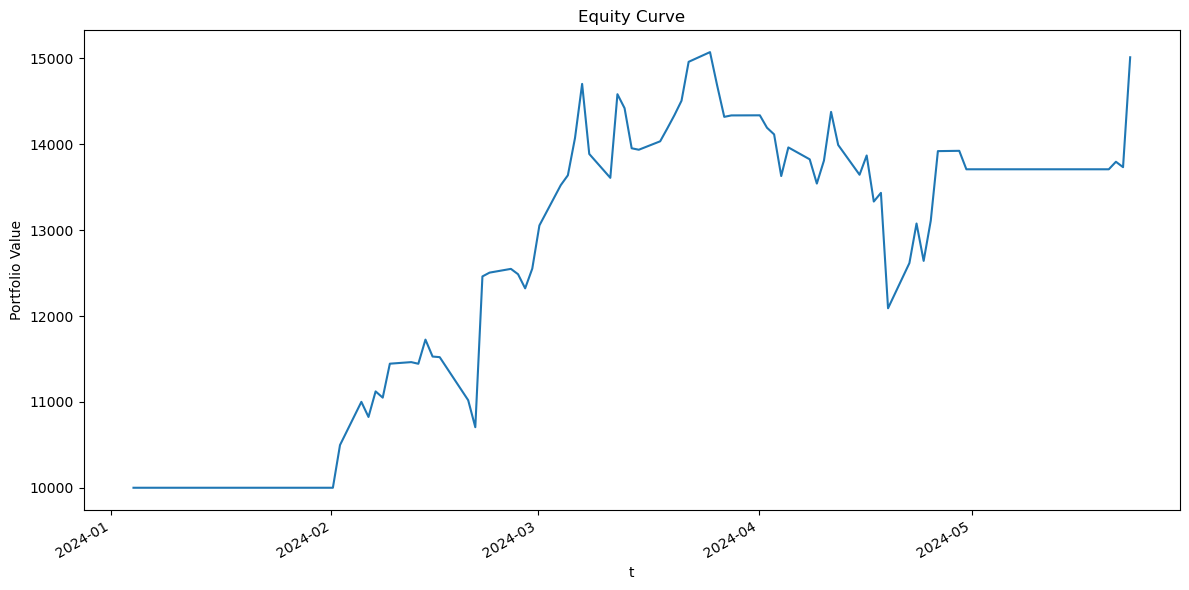

In [6]:
ax = result.equity_curve.plot(title="Equity Curve", figsize=(12, 6))
ax.set_ylabel("Portfolio Value")
ax.figure.tight_layout()